# Pythonセミナー 第4回 課題

このノートブックでは、次の2つの回帰モデルを作成します。

1. `feature_engineering_dataset.csv` を使い、各特徴量の二乗・三乗特徴量を追加して Lasso 回帰を行う
2. `Material_Lifespan_Dataset_encoded_sklearn.csv` を使い、SVRで `PredictedHours`（材料寿命）を予測する

第2回のノートブックと同じように、読み込み、前処理、学習、評価、可視化の順に進めます。

## uvで仮想環境を準備する

このフォルダには `pyproject.toml` を置いているので、ターミナルでは次のように環境を準備できます。

```bash
uv venv --python 3.11
uv sync
uv run python -m ipykernel install --user --name python-seminar-4 --display-name "Python Seminar 4 (.venv)"
uv run jupyter notebook
```

Jupyter上では、カーネルに `Python Seminar 4 (.venv)` を選びます。

In [1]:
#* ライブラリのインポート
from pathlib import Path
import os

#* Matplotlibのキャッシュを作業フォルダ内に作る
os.environ["MPLCONFIGDIR"] = str(Path.cwd() / ".matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

RANDOM_STATE = 42
DATA_DIR = Path(".")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 80)

Matplotlib is building the font cache; this may take a moment.


In [2]:
#* 回帰モデルの評価指標をまとめる関数を定義する
def regression_metrics(y_true, y_pred):
    return {
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


#* 実測値と予測値の散布図を表示する関数を定義する
def plot_actual_vs_predicted(y_train, pred_train, y_test, pred_test, title):
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=y_train, y=pred_train, label="Train", alpha=0.65)
    sns.scatterplot(x=y_test, y=pred_test, label="Test", alpha=0.8)

    min_value = min(y_train.min(), y_test.min(), pred_train.min(), pred_test.min())
    max_value = max(y_train.max(), y_test.max(), pred_train.max(), pred_test.max())
    plt.plot([min_value, max_value], [min_value, max_value], color="black", linestyle="--", linewidth=1)

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.legend()
    plt.show()

## 1. 特徴量エンジニアリング + Lasso回帰

`x1` から `x4` までの特徴量に対して、それぞれ二乗特徴量と三乗特徴量を追加します。Lasso回帰は不要な特徴量の係数を0に近づけるため、追加した特徴量の中から重要なものを選びやすいモデルです。

In [3]:
#* CSVファイルを読み込んで、データの先頭を確認する
feature_path = DATA_DIR / "feature_engineering_dataset.csv"
df_feature = pd.read_csv(feature_path)

display(df_feature.head())
display(df_feature.describe().round(3))

,x1,x2,x3,x4,y
0,-1.254599,-3.148671,-2.382943,1.727030,4.474510
1,4.507143,0.419009,-2.530212,2.966814,16.006309
2,2.319939,3.729458,4.062546,-2.495321,-1.629434
3,0.986585,2.322249,-2.504538,1.248741,1.787929
4,-3.439814,3.065611,-2.280503,0.717460,5.071840


,x1,x2,x3,x4,y
count,1000.000,1000.000,1000.000,1000.000,1000.000
mean,-0.097,0.070,0.024,-0.096,3.931
std,2.921,2.922,2.907,2.865,10.174
min,-4.954,-4.968,-5.000,-4.993,-23.903
25%,-2.640,-2.589,-2.386,-2.581,-1.257
50%,-0.032,0.187,0.006,-0.157,3.407
75%,2.443,2.605,2.591,2.375,9.433
max,4.997,4.994,4.978,4.996,38.729


In [4]:
#* 目的変数 y と説明変数 X に分ける
target_feature = "y"
X_feature = df_feature.drop(columns=[target_feature])
y_feature = df_feature[target_feature]

#* 各特徴量の二乗・三乗を追加する関数を定義する
def add_power_features(X):
    X_new = X.copy()
    original_columns = X.columns.tolist()

    for col in original_columns:
        X_new[f"{col}_squared"] = X_new[col] ** 2
        X_new[f"{col}_cubed"] = X_new[col] ** 3

    return X_new


#* 学習用データとテスト用データに分割する
X_train_raw, X_test_raw, y_train_feature, y_test_feature = train_test_split(
    X_feature,
    y_feature,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

#* 分割後に特徴量エンジニアリングを行う
X_train_power = add_power_features(X_train_raw)
X_test_power = add_power_features(X_test_raw)

print("元の特徴量数:", X_train_raw.shape[1])
print("二乗・三乗を追加した後の特徴量数:", X_train_power.shape[1])
display(X_train_power.head())

元の特徴量数: 4
二乗・三乗を追加した後の特徴量数: 12


,x1,x2,x3,x4,x1_squared,x1_cubed,x2_squared,x2_cubed,x3_squared,x3_cubed,x4_squared,x4_cubed
29,-4.535496,3.289155,1.541746,1.322822,20.570723,-93.298428,10.818539,35.583849,2.376981,3.664701,1.749857,2.314748
535,4.447657,-3.781139,3.341446,-3.703210,19.781655,87.982024,14.297013,-54.058993,11.165261,37.308117,13.713766,-50.784958
695,1.106200,-4.318277,0.190323,-4.698961,1.223679,1.353635,18.647515,-80.525135,0.036223,0.006894,22.080237,-103.754179
557,-4.712173,-0.889715,-2.004343,-0.121657,22.204577,-104.631812,0.791593,-0.704293,4.017392,-8.052232,0.014800,-0.001801
836,4.148459,-3.719043,4.932550,4.325549,17.209712,71.393785,13.831277,-51.439109,24.330051,120.009197,18.710372,80.932628


In [5]:
#* 比較用に、元の特徴量だけのLasso回帰も作成する
lasso_alphas = np.logspace(-4, 2, 120)

lasso_original = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LassoCV(alphas=lasso_alphas, cv=5, max_iter=20000, random_state=RANDOM_STATE)),
    ]
)

#* 二乗・三乗特徴量を使うLasso回帰モデルを作成する
lasso_power = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LassoCV(alphas=lasso_alphas, cv=5, max_iter=20000, random_state=RANDOM_STATE)),
    ]
)

#* モデルを学習させる
lasso_original.fit(X_train_raw, y_train_feature)
lasso_power.fit(X_train_power, y_train_feature)

#* 学習データとテストデータに対して予測を行う
pred_train_original = lasso_original.predict(X_train_raw)
pred_test_original = lasso_original.predict(X_test_raw)
pred_train_power = lasso_power.predict(X_train_power)
pred_test_power = lasso_power.predict(X_test_power)

#* 評価指標を表にまとめる
lasso_results = pd.DataFrame(
    [
        regression_metrics(y_train_feature, pred_train_original),
        regression_metrics(y_test_feature, pred_test_original),
        regression_metrics(y_train_feature, pred_train_power),
        regression_metrics(y_test_feature, pred_test_power),
    ],
    index=pd.MultiIndex.from_tuples(
        [
            ("Lasso: original", "Train"),
            ("Lasso: original", "Test"),
            ("Lasso: +squared/+cubed", "Train"),
            ("Lasso: +squared/+cubed", "Test"),
        ],
        names=["Model", "Data"],
    ),
)

display(lasso_results.round(3))
print("元の特徴量だけのLasso alpha:", round(lasso_original.named_steps["model"].alpha_, 6))
print("二乗・三乗特徴量ありのLasso alpha:", round(lasso_power.named_steps["model"].alpha_, 6))

RMSE    MAE     R2
Model                  Data                      
Lasso: original        Train  5.766  4.683  0.676
                       Test   5.990  4.905  0.662
Lasso: +squared/+cubed Train  2.038  1.637  0.960
                       Test   2.060  1.632  0.960

元の特徴量だけのLasso alpha: 0.212682
二乗・三乗特徴量ありのLasso alpha: 0.066608


,coefficient,abs_coefficient
x4_cubed,9.1611,9.1611
x1_squared,3.6824,3.6824
x1,-0.0000,0.0000
x2,-0.0000,0.0000
x3,0.0000,0.0000
x4,0.0000,0.0000
x1_cubed,-0.0000,0.0000
x2_squared,-0.0000,0.0000
x2_cubed,-0.0000,0.0000
x3_squared,-0.0000,0.0000


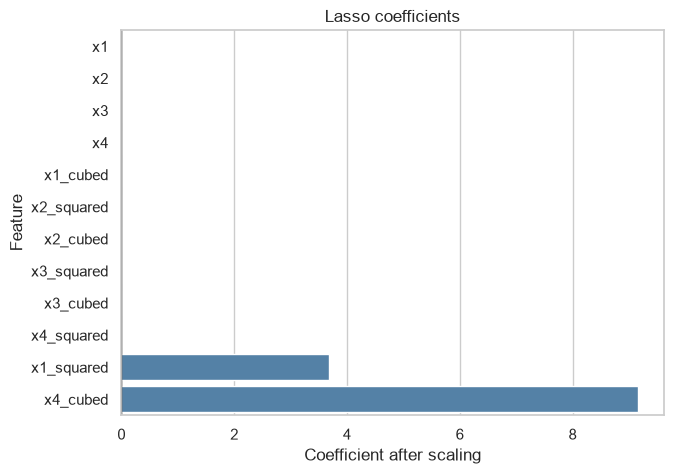

In [6]:
#* Lasso回帰の係数を確認する
#* StandardScaler後の係数なので、絶対値が大きいほど予測への影響が大きいと見る
lasso_coefficients = pd.Series(
    lasso_power.named_steps["model"].coef_,
    index=X_train_power.columns,
    name="coefficient",
)

coef_table = (
    lasso_coefficients.to_frame()
    .assign(abs_coefficient=lasso_coefficients.abs())
    .sort_values("abs_coefficient", ascending=False)
)

display(coef_table.round(4))

top_coef = coef_table.head(12).sort_values("coefficient")
plt.figure(figsize=(7, 5))
sns.barplot(data=top_coef.reset_index(), x="coefficient", y="index", color="steelblue")
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Coefficient after scaling")
plt.ylabel("Feature")
plt.title("Lasso coefficients")
plt.show()

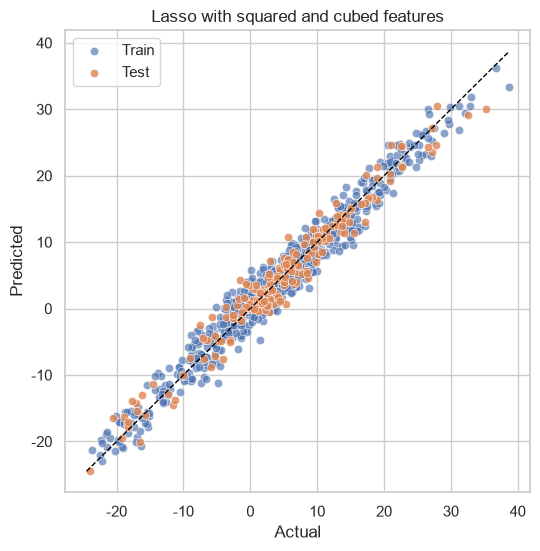

In [7]:
#* 実測値と予測値の散布図で、予測がどれくらい当たっているかを確認する
plot_actual_vs_predicted(
    y_train_feature,
    pred_train_power,
    y_test_feature,
    pred_test_power,
    "Lasso with squared and cubed features",
)

## 2. SVRで材料寿命 `PredictedHours` を予測する

`Material_Lifespan_Dataset_encoded_sklearn.csv` はカテゴリ変数がすでにOne-Hot Encodingされているデータです。SVRは特徴量のスケールに影響を受けやすいので、`StandardScaler` と `SVR` を `Pipeline` でまとめて使います。

In [8]:
#* 材料寿命データを読み込む
#* 課題文のファイル名と実ファイル名が違う場合に備えて、候補から存在するものを選ぶ
material_candidates = [
    DATA_DIR / "Material_Lifespan_Dataset.csv",
    DATA_DIR / "Material_Lifespan_Dataset_encoded_sklearn.csv",
]
material_path = next((path for path in material_candidates if path.exists()), None)

if material_path is None:
    raise FileNotFoundError("Material_Lifespan_Dataset.csv が見つかりません。")

df_material = pd.read_csv(material_path)

#* 目的変数名を確認する
if "PredictedHours" in df_material.columns:
    target_material = "PredictedHours"
elif "PredictiedHours" in df_material.columns:
    target_material = "PredictiedHours"
else:
    raise ValueError("目的変数 PredictedHours が見つかりません。")

print("使用したファイル:", material_path.name)
print("目的変数:", target_material)
display(df_material.head())
display(df_material.describe().round(3))

使用したファイル: Material_Lifespan_Dataset_encoded_sklearn.csv
目的変数: PredictedHours


,PredictedHours,CoolRate,QuenchDuration,ForgeDuration,HeatProcessTime,NickelComposition,IronComposition,CobaltComposition,ChromiumComposition,MinorDefects,MajorDefects,EdgeDefects,ComponentType_Blade,ComponentType_Block,ComponentType_Nozzle,ComponentType_Valve,StructureType_colGrain,StructureType_equiGrain,StructureType_singleGrain,InitialPosition_Bottom,InitialPosition_Top,FormationMethod_Continuous,FormationMethod_Die,FormationMethod_Investment
0,1461.797,12.836,3.803,6.515,47.005,65.450,16.618,16.510,0.938,10,0,0,0,0,1,0,0,1,0,1,0,0,1,0
1,1825.977,19.032,2.593,3.521,45.246,54.162,34.916,6.063,4.292,19,0,0,0,1,0,0,0,0,1,1,0,0,0,1
2,707.101,28.418,0.772,1.327,9.639,52.565,36.486,8.927,3.355,35,3,0,1,0,0,0,0,1,0,1,0,0,0,1
3,1086.370,9.084,1.990,2.201,20.009,56.665,23.436,17.040,2.827,0,1,0,0,0,1,0,1,0,0,0,1,1,0,0
4,1813.529,16.196,4.092,3.881,15.904,60.502,26.995,11.382,1.564,10,0,0,1,0,0,0,1,0,0,0,1,0,1,0


,PredictedHours,CoolRate,QuenchDuration,ForgeDuration,HeatProcessTime,NickelComposition,IronComposition,CobaltComposition,ChromiumComposition,MinorDefects,MajorDefects,EdgeDefects,ComponentType_Blade,ComponentType_Block,ComponentType_Nozzle,ComponentType_Valve,StructureType_colGrain,StructureType_equiGrain,StructureType_singleGrain,InitialPosition_Bottom,InitialPosition_Top,FormationMethod_Continuous,FormationMethod_Die,FormationMethod_Investment
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,1298.230,17.641,2.764,5.463,30.190,60.239,24.544,12.425,2.767,17.311,0.550,0.292,0.237,0.253,0.245,0.265,0.317,0.340,0.343,0.497,0.503,0.327,0.366,0.307
std,340.891,7.497,1.318,2.604,16.886,5.831,7.367,4.332,1.327,12.268,1.164,1.199,0.425,0.435,0.430,0.442,0.466,0.474,0.475,0.500,0.500,0.469,0.482,0.461
min,420.800,4.918,0.492,1.016,1.024,49.034,6.724,4.938,0.506,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,1040.893,11.121,1.641,3.172,16.218,55.189,19.318,8.610,1.594,7.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,1267.748,17.763,2.752,5.480,29.422,60.502,24.617,12.529,2.862,18.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000
75%,1561.213,24.350,3.957,7.739,45.110,65.141,29.881,16.047,3.925,26.000,0.000,0.000,0.000,1.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
max,2155.117,30.585,5.079,10.089,60.071,71.106,43.636,20.265,5.086,61.000,4.000,8.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [9]:
#* 目的変数 y と説明変数 X に分ける
X_material = df_material.drop(columns=[target_material])
y_material = df_material[target_material]

#* データを学習用とテスト用に分割する
X_train_material, X_test_material, y_train_material, y_test_material = train_test_split(
    X_material,
    y_material,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print("学習データ:", X_train_material.shape)
print("テストデータ:", X_test_material.shape)

学習データ: (800, 23)
テストデータ: (200, 23)


In [10]:
#* SVRモデルを作成する
#* SVRはスケールの影響を受けるため、標準化とモデルをPipelineでまとめる
svr_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", SVR()),
    ]
)

#* RBFカーネルとLinearカーネルを比較し、良いパラメータをGridSearchCVで探す
svr_param_grid = [
    {
        "model__kernel": ["rbf"],
        "model__C": [1000, 3000, 10000],
        "model__gamma": [0.001, 0.003, 0.006, 0.01, 0.02],
        "model__epsilon": [5, 10, 20, 30],
    },
    {
        "model__kernel": ["linear"],
        "model__C": [0.1, 1, 10, 100],
        "model__epsilon": [1, 5, 10, 20],
    },
]

svr_grid = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=svr_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,
    return_train_score=True,
)

svr_grid.fit(X_train_material, y_train_material)
best_svr = svr_grid.best_estimator_

print("最良パラメータ:", svr_grid.best_params_)
print("交差検証のRMSE:", round(-svr_grid.best_score_, 3))

svr_cv_results = pd.DataFrame(svr_grid.cv_results_)
svr_cv_results["mean_cv_RMSE"] = -svr_cv_results["mean_test_score"]
display(
    svr_cv_results
    .sort_values("rank_test_score")
    [["rank_test_score", "mean_cv_RMSE", "std_test_score", "params"]]
    .head(10)
)

最良パラメータ: {'model__C': 10000, 'model__epsilon': 30, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
交差検証のRMSE: 185.065


,rank_test_score,mean_cv_RMSE,std_test_score,params
58,1,185.064819,7.042995,"{'model__C': 10000, 'model__epsilon': 30, 'mod..."
53,2,185.481659,6.939159,"{'model__C': 10000, 'model__epsilon': 20, 'mod..."
48,3,185.942284,7.219197,"{'model__C': 10000, 'model__epsilon': 10, 'mod..."
43,4,186.383151,7.437820,"{'model__C': 10000, 'model__epsilon': 5, 'mode..."
47,5,187.683454,7.683150,"{'model__C': 10000, 'model__epsilon': 10, 'mod..."
42,6,187.711263,7.801529,"{'model__C': 10000, 'model__epsilon': 5, 'mode..."
52,7,188.132858,7.836865,"{'model__C': 10000, 'model__epsilon': 20, 'mod..."
57,8,188.684958,7.877474,"{'model__C': 10000, 'model__epsilon': 30, 'mod..."
39,9,189.807173,6.193462,"{'model__C': 3000, 'model__epsilon': 30, 'mode..."
34,10,190.265303,6.471588,"{'model__C': 3000, 'model__epsilon': 20, 'mode..."


In [11]:
#* 最良モデルで予測し、評価指標を確認する
pred_train_svr = best_svr.predict(X_train_material)
pred_test_svr = best_svr.predict(X_test_material)

svr_results = pd.DataFrame(
    [
        regression_metrics(y_train_material, pred_train_svr),
        regression_metrics(y_test_material, pred_test_svr),
    ],
    index=pd.Index(["Train", "Test"], name="Data"),
)

display(svr_results.round(3))

prediction_sample = pd.DataFrame(
    {
        "ActualHours": y_test_material,
        "PredictedHours": pred_test_svr,
        "Residual": y_test_material - pred_test_svr,
    }
).round(3)

display(prediction_sample.head(10))

,RMSE,MAE,R2
Data,,,
Train,103.789,71.333,0.910
Test,178.038,142.317,0.694


,ActualHours,PredictedHours,Residual
521,1567.417,1554.393,13.024
737,1826.765,1676.833,149.932
740,973.564,1075.344,-101.780
660,1380.756,1482.235,-101.479
411,1342.511,1398.631,-56.120
678,1038.054,901.634,136.420
626,1385.680,1321.695,63.985
513,870.533,859.677,10.856
859,1127.645,983.701,143.944
136,1564.055,1600.123,-36.068


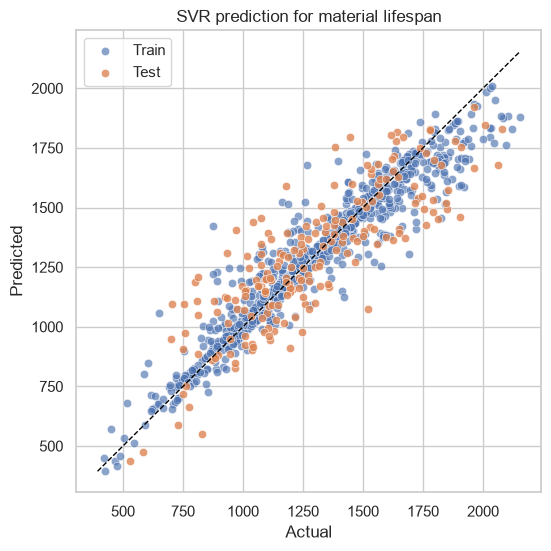

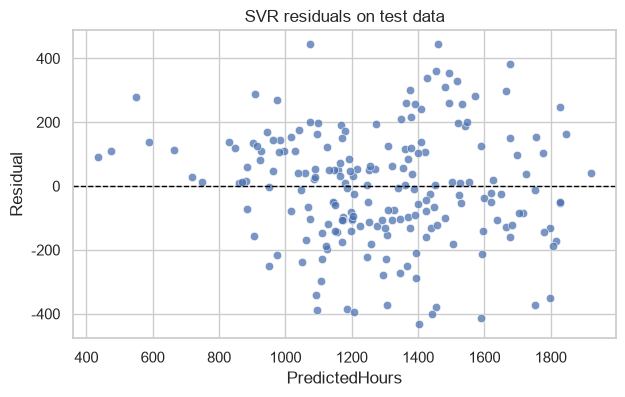

In [12]:
#* 実測値と予測値の散布図を表示する
plot_actual_vs_predicted(
    y_train_material,
    pred_train_svr,
    y_test_material,
    pred_test_svr,
    "SVR prediction for material lifespan",
)

#* 残差を確認する
plt.figure(figsize=(7, 4))
sns.scatterplot(x=pred_test_svr, y=y_test_material - pred_test_svr, alpha=0.75)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("PredictedHours")
plt.ylabel("Residual")
plt.title("SVR residuals on test data")
plt.show()

In [13]:
#* 最後に、今回作成した2つのモデルのテストデータ評価をまとめる
summary = pd.DataFrame(
    [
        regression_metrics(y_test_feature, pred_test_power),
        regression_metrics(y_test_material, pred_test_svr),
    ],
    index=pd.Index(
        ["Lasso + squared/cubed features", "SVR for PredictedHours"],
        name="Model",
    ),
)

display(summary.round(3))

,RMSE,MAE,R2
Model,,,
Lasso + squared/cubed features,2.060,1.632,0.960
SVR for PredictedHours,178.038,142.317,0.694
